# Stage 3: HTML Feature Classification
### Multimodal Phishing Detection — Group 15, Binus University

**Model:** Random Forest  
**Data:** PhiUSIIL_Phishing_URL_Dataset.csv (HTML-derived features)

## Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
warnings.filterwarnings('ignore')

BASE       = os.path.abspath('..')
FIG_DIR    = os.path.join(BASE, 'result', 'figures')
METRIC_DIR = os.path.join(BASE, 'result', 'metrics')
print('Libraries imported.')

Libraries imported.


## Cell 2: Load Dataset

In [2]:
DATA_PATH = os.path.join(BASE, 'data', 'PhiUSIIL_Phishing_URL_Dataset.csv')

HTML_FEATURES = [
    'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore',
    'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive',
    'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup',
    'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
    'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
    'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
    'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef'
]
LABEL_COL = 'label'  # 0=phishing, 1=legitimate

df = pd.read_csv(DATA_PATH, usecols=HTML_FEATURES + [LABEL_COL], nrows=50000)
df = df.dropna().reset_index(drop=True)
print(f'Loaded: {len(df)} rows, {len(HTML_FEATURES)} HTML features')
print(df[LABEL_COL].value_counts().rename({0: 'Phishing', 1: 'Legitimate'}))
df.head()

Loaded: 50000 rows, 28 HTML features
label
Legitimate    29374
Phishing      20626
Name: count, dtype: int64


,LineOfCode,LargestLineLength,HasTitle,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,558,9381,1,0.000000,0.000000,0,1,1,0,0,...,0,0,1,34,20,28,119,0,124,1
1,618,9381,1,55.555556,55.555556,1,1,0,0,0,...,0,0,1,50,9,8,39,0,217,1
2,467,682,1,46.666667,46.666667,0,1,1,0,0,...,0,0,1,10,2,7,42,2,5,1
3,6356,26824,1,0.000000,0.000000,0,1,1,0,0,...,1,1,1,3,27,15,22,1,31,1
4,6089,28404,1,100.000000,100.000000,0,1,1,1,1,...,1,0,1,244,15,34,72,1,85,1


## Cell 3: Train/Test Split

In [3]:
X = df[HTML_FEATURES]
y = df[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 40000 | Test: 10000


## Cell 4: Train Random Forest

In [4]:
model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


## Cell 5: Evaluate Model

In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('='*50)
print('HASIL EVALUASI -- STAGE 3: HTML CLASSIFIER')
print('='*50)
print(f'Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(classification_report(y_test, y_pred, target_names=['Phishing (0)', 'Legitimate (1)']))

stage3_metrics = {
    'Stage': 'Stage 3 - HTML', 'Model': 'Random Forest',
    'Accuracy': round(accuracy, 4), 'Precision': round(precision, 4),
    'Recall': round(recall, 4), 'F1-Score': round(f1, 4)
}

HASIL EVALUASI -- STAGE 3: HTML CLASSIFIER
Accuracy  : 0.9974 (99.74%)
Precision : 0.9974
Recall    : 0.9974
F1-Score  : 0.9974
                precision    recall  f1-score   support

  Phishing (0)       1.00      0.99      1.00      4125
Legitimate (1)       1.00      1.00      1.00      5875

      accuracy                           1.00     10000
     macro avg       1.00      1.00      1.00     10000
  weighted avg       1.00      1.00      1.00     10000



## Cell 6: Confusion Matrix

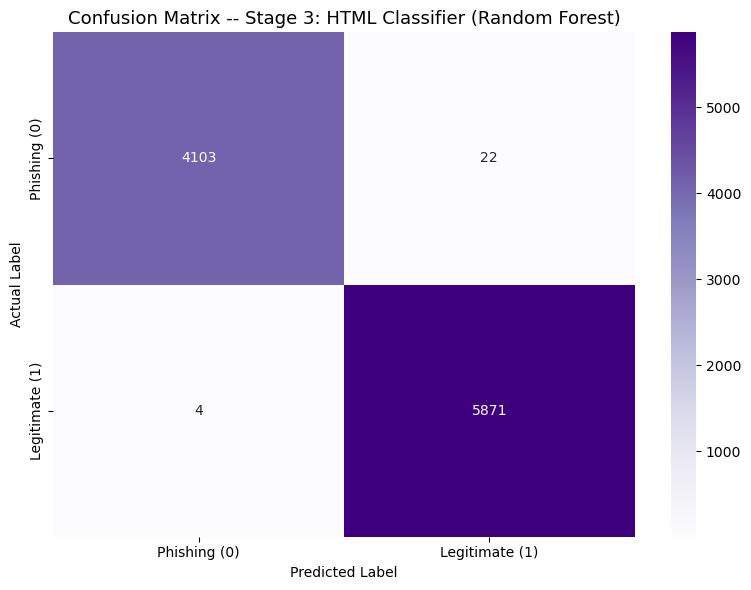

TN=4103  FP=22  FN=4  TP=5871


In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=['Phishing (0)', 'Legitimate (1)'],
    yticklabels=['Phishing (0)', 'Legitimate (1)'])
plt.title('Confusion Matrix -- Stage 3: HTML Classifier (Random Forest)', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stage3_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

## Cell 7: Feature Importance

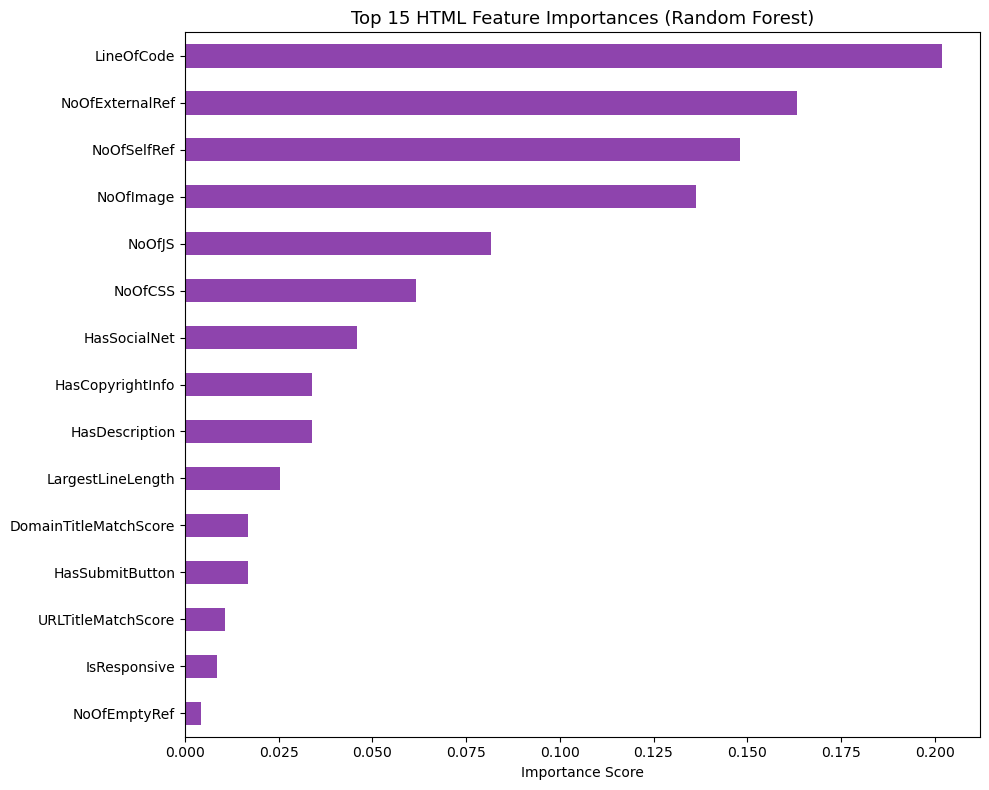

In [7]:
importances = pd.Series(model.feature_importances_, index=HTML_FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='#8e44ad')
plt.gca().invert_yaxis()
plt.title('Top 15 HTML Feature Importances (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stage3_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 8: Perbandingan Semua Stage

In [8]:
stage1 = pd.read_csv(os.path.join(METRIC_DIR, 'stage1_metrics.csv'))
stage2 = pd.read_csv(os.path.join(METRIC_DIR, 'stage2_metrics.csv'))

cols = ['Stage', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison = pd.concat([
    stage1[cols],
    stage2[cols],
    pd.DataFrame([stage3_metrics])[cols]
], ignore_index=True)
comparison.to_csv(os.path.join(METRIC_DIR, 'all_stages_comparison.csv'), index=False)
print(comparison.to_string(index=False))

            Stage                        Model  Accuracy  Precision  Recall  F1-Score
Stage 1 - Message TF-IDF + Logistic Regression    0.9825     0.9827  0.9825    0.9825
    Stage 2 - URL                      XGBoost    0.9999     0.9999  0.9999    0.9999
   Stage 3 - HTML                Random Forest    0.9974     0.9974  0.9974    0.9974


## Cell 9: Comparison Chart

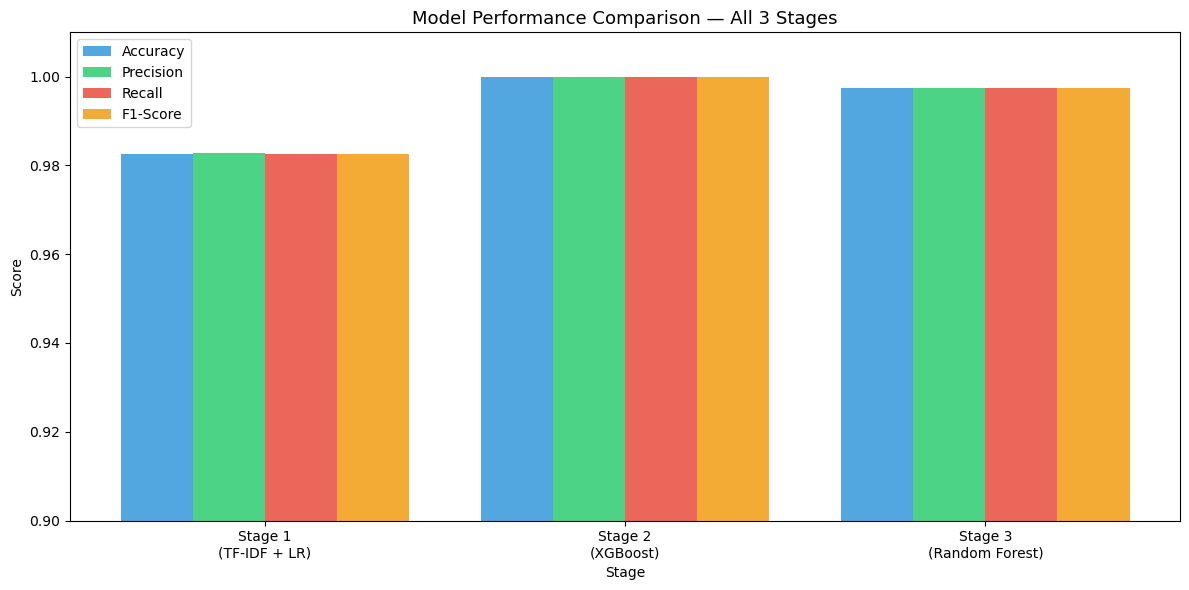

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.2
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i*width, comparison[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xlabel('Stage')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All 3 Stages', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Stage 1\n(TF-IDF + LR)', 'Stage 2\n(XGBoost)', 'Stage 3\n(Random Forest)'])
ax.set_ylim(0.9, 1.01)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'all_stages_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Cell 10: Save Model & Metrics

In [10]:
joblib.dump(model, os.path.join(METRIC_DIR, 'stage3_model_rf.pkl'))
pd.DataFrame([stage3_metrics]).to_csv(os.path.join(METRIC_DIR, 'stage3_metrics.csv'), index=False)
print('stage3_model_rf.pkl saved')
print('stage3_metrics.csv saved')
print('all_stages_comparison.csv saved')
print('SEMUA STAGE SELESAI!')

stage3_model_rf.pkl saved
stage3_metrics.csv saved
all_stages_comparison.csv saved
SEMUA STAGE SELESAI!
